In [1]:
from utilities.data_loader import load_data

train_prices, train_dates, test_prices, test_dates = load_data("./data/BTC-Daily.csv")

In [2]:
from utilities.filters import lma_filter, ema_filter, wma, sma_filter

print(sma_filter(3))
print(sum(sma_filter(3)))

print(lma_filter(3))
print(sum(lma_filter(3)))

print(ema_filter(3, 0.5))
print(sum(ema_filter(3, 0.5)))

[0.33333333 0.33333333 0.33333333]
1.0
[0.5        0.33333333 0.16666667]
1.0
[0.57142857 0.28571429 0.14285714]
1.0


In [3]:
P = train_prices
N = 3
print(wma(P, N, sma_filter(N)))
print(wma(P, N, lma_filter(N)))
print(wma(P, N, ema_filter(N, 0.5)))


[-124.59333333  125.42666667  375.44666667 ... 7309.26       7300.67333333
 7258.04666667]
[3.43333333e-01 2.51000000e+02 3.74956667e+02 ... 7.33251667e+03
 7.28800667e+03 7.22185000e+03]
[  54.04857143  268.96        374.72571429 ... 7340.09142857 7278.32571429
 7214.20857143]


DO buy at time 58 with price 253.09
Do sell at time 67 with price 227.35
DO buy at time 79 with price 234.01
Do sell at time 111 with price 262.01
DO buy at time 129 with price 255.83
Do sell at time 132 with price 243.53
DO buy at time 154 with price 231.96
Do sell at time 171 with price 232.24
DO buy at time 177 with price 239.68
Do sell at time 180 with price 235.34
DO buy at time 197 with price 231.51
Do sell at time 236 with price 277.93
DO buy at time 239 with price 289.34
Do sell at time 248 with price 282.72
DO buy at time 282 with price 240.45
Do sell at time 291 with price 229.3
Final cash 646.7449497156921


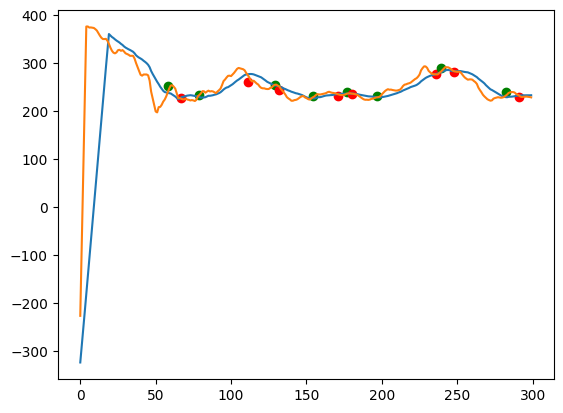

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
P = train_prices[:300]

Long_N = 20
Short_N = 5
long = (wma(P, Long_N, sma_filter(Long_N)))
short = (wma(P, Short_N, sma_filter(Short_N)))
diff = short - long
# print(len(diff))
# print("signs", np.sign(diff))
Sign_kernel = np.array([0.5, -0.5])
signals = (wma(np.sign(diff), 2, Sign_kernel))

# Replace longest N with 0 to invalidate trade window from padding induced trade
longest = max(Long_N, Short_N)
signals[:longest] = 0

# print("signals", signals)
# print("len signals", len(signals))
# print("signals != 0", signals[signals != 0])
cash = 1000.0 
btc_held = 0.0
fee = 0.03

for t in range(len(P)):
    if signals[t] == 1 and btc_held == 0:
        print(f"DO buy at time {t} with price {P[t]}")
        spend = cash * (1 - fee)
        btc_held = spend / P[t]
        cash = 0
        plt.plot(t, P[t], 'go')
    if signals[t] == -1 and btc_held > 0:
        print(f"Do sell at time {t} with price {P[t]}")
        gain = btc_held * P[t]
        gainminusfee = gain * (1 - fee)
        cash = gainminusfee
        btc_held = 0
        plt.plot(t, P[t], 'ro')
# If at the end still holding bitcoin, sell them
if btc_held > 0:
    print(f"Do sell at time {t} with price {P[t]}")
    gain = btc_held * P[t]
    gainminusfee = gain * (1 - fee)
    cash += gainminusfee
    plt.plot(t, P[t], 'ro')
print("Final cash", cash)


plt.plot(long)
plt.plot(short)
plt.show()


DO buy at time 19 with price 321.1
Do sell at time 58 with price 253.09
DO buy at time 67 with price 227.35
Do sell at time 79 with price 234.01
DO buy at time 111 with price 262.01
Do sell at time 129 with price 255.83
DO buy at time 132 with price 243.53
Do sell at time 154 with price 231.96
DO buy at time 171 with price 232.24
Do sell at time 177 with price 239.68
DO buy at time 180 with price 235.34
Do sell at time 197 with price 231.51
DO buy at time 236 with price 277.93
Do sell at time 239 with price 289.34
DO buy at time 248 with price 282.72
Do sell at time 282 with price 240.45
DO buy at time 291 with price 229.3
Do sell at time 299 with price 229.41
Final cash 392.1732419017415


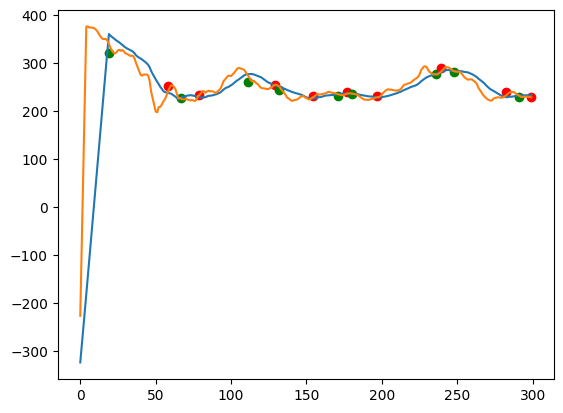

np.float64(392.1732419017415)

In [6]:
from optimizer.evaluator import evaluate
temp_short = np.copy(short)
temp_long = np.copy(long)
evaluate(P, temp_short, temp_long)